### Uploading a CSV file

You can upload a CSV file directly to your Colab environment using the following code. Once uploaded, the file will be accessible in the Colab instance's file system.

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving customer_churn.csv to customer_churn.csv
User uploaded file "customer_churn.csv" with length 685959 bytes


In [2]:
import pandas as pd

df = pd.read_csv("customer_churn.csv")
print("Rows and Columns:", df.shape)
df.head()



Rows and Columns: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print(df.columns.tolist())

['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.isnull().sum()


,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [7]:
df = df.drop(columns=["CustomerId", "Surname", "Year"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [10]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

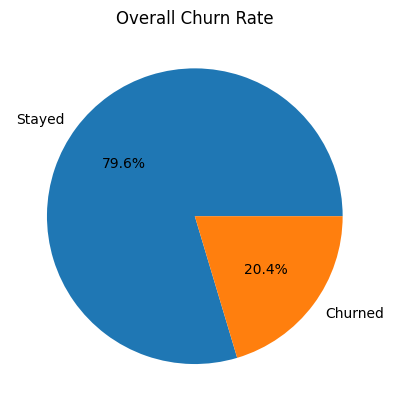

In [12]:
df['Exited'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Stayed', 'Churned'])
plt.title('Overall Churn Rate')
plt.ylabel('')
plt.show()

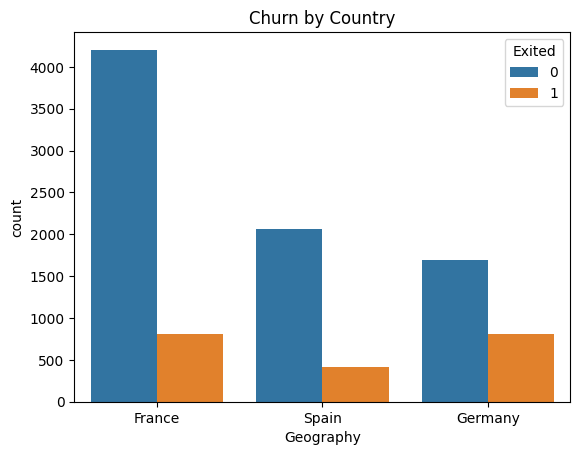

In [13]:
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Churn by Country')
plt.show()

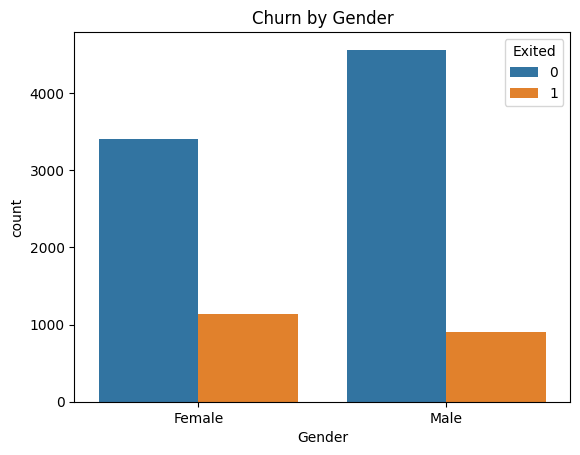

In [14]:
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title('Churn by Gender')
plt.show()

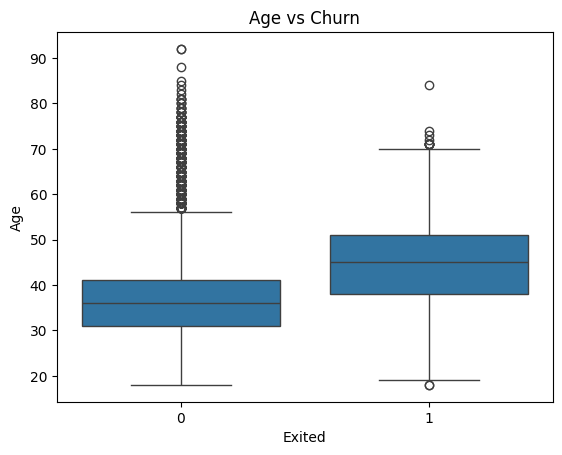

In [15]:
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age vs Churn')
plt.show()

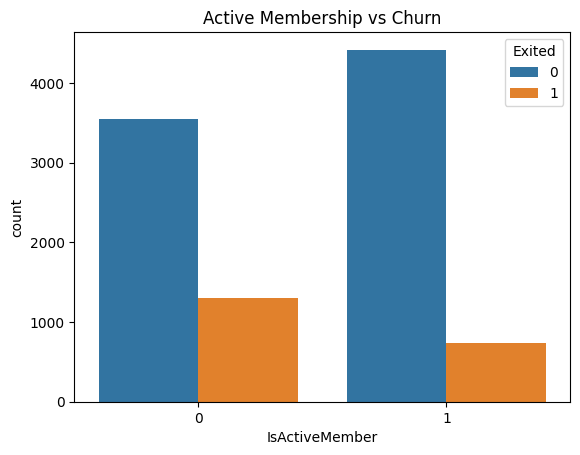

In [16]:
sns.countplot(data=df, x='IsActiveMember', hue='Exited')
plt.title('Active Membership vs Churn')
plt.show()

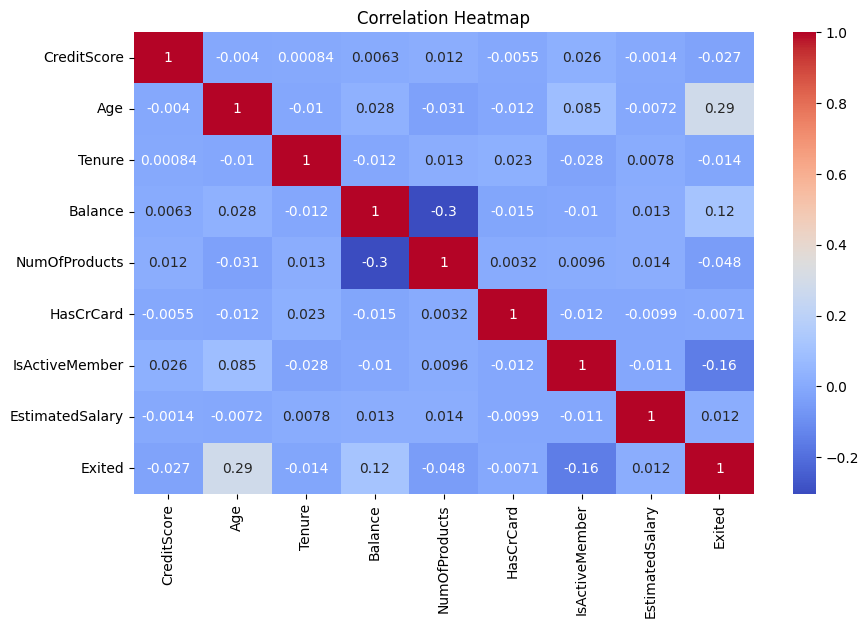

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
print("Churn % by Country:")
print(df.groupby('Geography')['Exited'].mean() * 100)

print("\nChurn % by Gender:")
print(df.groupby('Gender')['Exited'].mean() * 100)

print("\nChurn % by Active Membership:")
print(df.groupby('IsActiveMember')['Exited'].mean() * 100)

Churn % by Country:
Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

Churn % by Gender:
Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

Churn % by Active Membership:
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [19]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [20]:
# Balance-to-Salary ratio: how much of their salary is sitting in the bank
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# Product density: products per year of tenure (avoid divide by 0)
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# Engagement-product interaction: active members using many products
df['EngagementProduct'] = df['IsActiveMember'] * df['NumOfProducts']

# Age-tenure interaction: older customers who've stayed a long time
df['AgeTenure'] = df['Age'] * df['Tenure']

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,0.333333,1,84
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744670,0.500000,1,41
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401362,0.333333,0,336
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,1.000000,0,39
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587035,0.333333,1,86


In [21]:
print(df.shape)
print(df.columns.tolist())

(10000, 16)
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProduct', 'AgeTenure']


In [22]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print(X.shape)
print(y.shape)

(10000, 15)
(10000,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8000, 15)
Test set size: (2000, 15)


In [24]:
print("Training churn rate:", y_train.mean() * 100)
print("Test churn rate:", y_test.mean() * 100)

Training churn rate: 20.375
Test churn rate: 20.349999999999998


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [27]:
y_pred_log = log_model.predict(X_test_scaled)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print()
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8065

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1593
           1       0.57      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000



In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42, max_depth=6)
tree_model.fit(X_train, y_train)  # Note: trees don't need scaled data!

y_pred_tree = tree_model.predict(X_test)

In [30]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.86
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [31]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

In [32]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_forest))
print(classification_report(y_test, y_pred_forest))

Random Forest Accuracy: 0.8655
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.83      0.43      0.56       407

    accuracy                           0.87      2000
   macro avg       0.85      0.70      0.74      2000
weighted avg       0.86      0.87      0.85      2000



In [33]:
forest_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=8,
    class_weight='balanced'  # tells the model to pay more attention to the minority class
)
forest_balanced.fit(X_train, y_train)

y_pred_balanced = forest_balanced.predict(X_test)

print("Balanced Random Forest Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Balanced Random Forest Accuracy: 0.825
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1593
           1       0.55      0.71      0.62       407

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.85      0.82      0.83      2000



In [34]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, prob_log))

# Random Forest (original)
prob_forest = forest_model.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC:", roc_auc_score(y_test, prob_forest))

# Balanced Random Forest
prob_balanced = forest_balanced.predict_proba(X_test)[:, 1]
print("Balanced Random Forest ROC-AUC:", roc_auc_score(y_test, prob_balanced))

Logistic Regression ROC-AUC: 0.773440620898248
Random Forest ROC-AUC: 0.8640674572877962
Balanced Random Forest ROC-AUC: 0.8654108654108653


In [35]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': forest_balanced.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

               Feature  Importance
1                  Age    0.298050
4        NumOfProducts    0.185320
13   EngagementProduct    0.091718
3              Balance    0.065404
14           AgeTenure    0.060102
8    Geography_Germany    0.057812
11  BalanceSalaryRatio    0.049710
6       IsActiveMember    0.037665
12      ProductDensity    0.035299
0          CreditScore    0.035023
7      EstimatedSalary    0.034131
2               Tenure    0.023837
10         Gender_Male    0.015423
9      Geography_Spain    0.006402
5            HasCrCard    0.004104


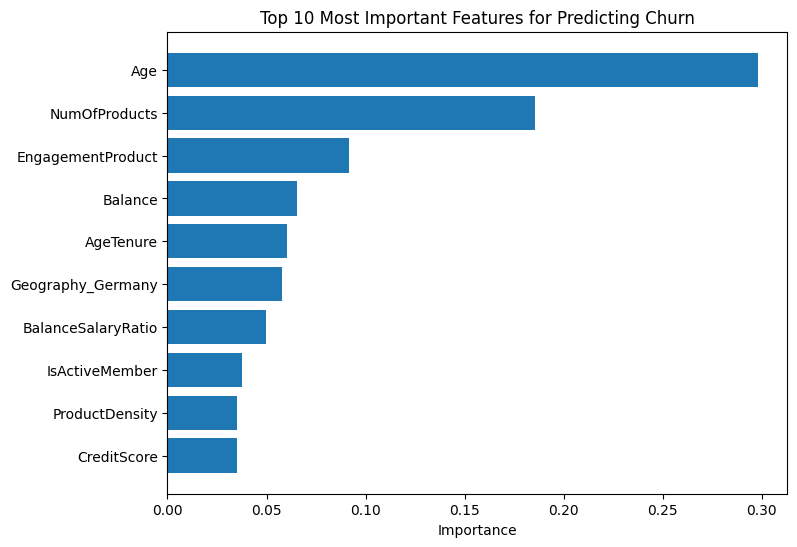

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Predicting Churn')
plt.gca().invert_yaxis()
plt.show()

In [37]:
!pip install shap
import shap

In [38]:
explainer = shap.TreeExplainer(forest_balanced)
shap_values = explainer.shap_values(X_test)

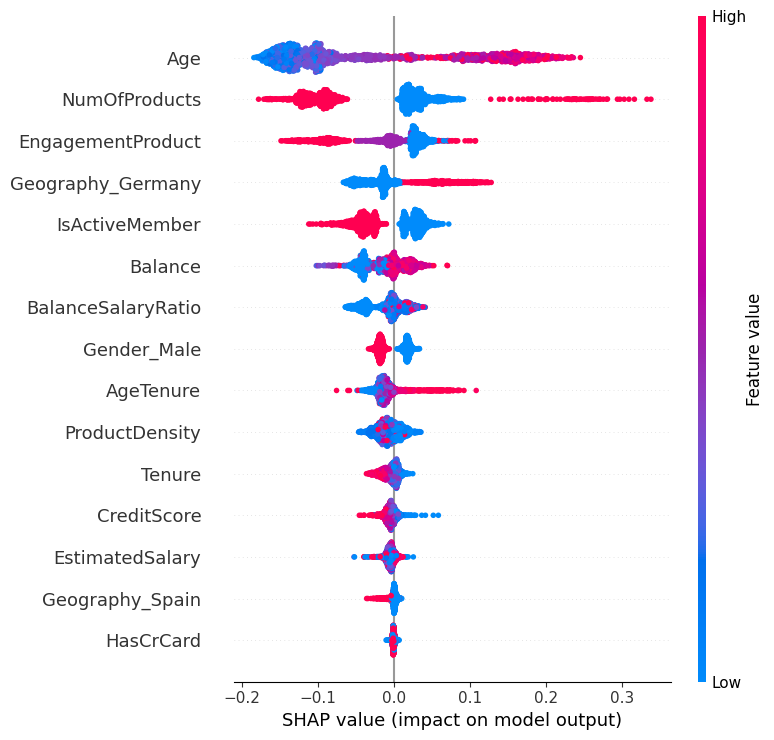

In [39]:
shap.summary_plot(shap_values[:,:,1], X_test)

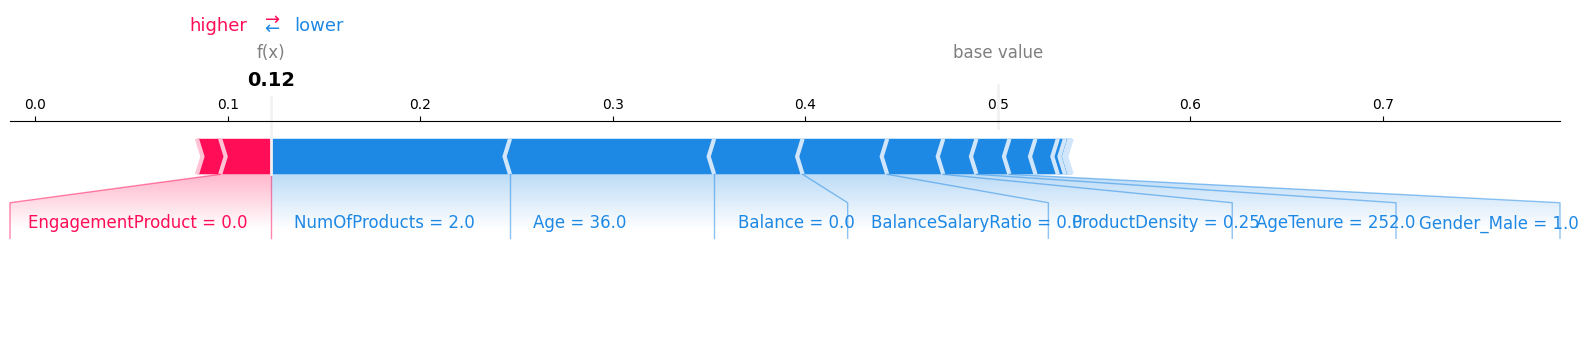

In [40]:
customer_index = 0  # try changing this to any number 0-1999

shap.force_plot(
    explainer.expected_value[1],
    shap_values[customer_index,:,1],
    X_test.iloc[customer_index,:],
    matplotlib=True
)

In [41]:
import pandas as pd

df = pd.read_csv('customer_churn.csv')  # or your uploaded path
df = df.drop(columns=['CustomerId', 'Surname', 'Year'])

In [42]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [43]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['EngagementProduct'] = df['IsActiveMember'] * df['NumOfProducts']
df['AgeTenure'] = df['Age'] * df['Tenure']

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

forest_balanced = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=8, class_weight='balanced'
)
forest_balanced.fit(X_train, y_train)

print("Model retrained successfully")
print("Accuracy:", forest_balanced.score(X_test, y_test))

Model retrained successfully
Accuracy: 0.825


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df.to_csv('/content/drive/MyDrive/customer_churn_cleaned.csv', index=False)

import joblib
joblib.dump(forest_balanced, '/content/drive/MyDrive/churn_model.pkl')
joblib.dump(list(X_train.columns), '/content/drive/MyDrive/model_columns.pkl')

print("Saved successfully")

Saved successfully


In [47]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

st.set_page_config(page_title="Customer Churn Dashboard", layout="wide")

model = joblib.load('/content/drive/MyDrive/churn_model.pkl')
model_columns = joblib.load('/content/drive/MyDrive/model_columns.pkl')
df = pd.read_csv('/content/drive/MyDrive/customer_churn_cleaned.csv')

st.title("📊 Customer Churn Analytics Dashboard")

tab1, tab2, tab3, tab4 = st.tabs([
    "🏠 Overview", "🎯 Risk Calculator", "📈 Feature Importance", "🔮 What-If Simulator"
])

with tab1:
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Customers", f"{len(df):,}")
    col2.metric("Churn Rate", f"{df['Exited'].mean()*100:.1f}%")
    col3.metric("Avg Age", f"{df['Age'].mean():.0f}")

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Churn Probability Distribution")
        probs = model.predict_proba(df[model_columns])[:, 1]
        fig, ax = plt.subplots()
        ax.hist(probs, bins=30, color='#1D9E75')
        ax.set_xlabel("Predicted churn probability")
        ax.set_ylabel("Number of customers")
        st.pyplot(fig)

    with col2:
        st.subheader("Age vs Churn")
        fig, ax = plt.subplots()
        sns.boxplot(data=df, x='Exited', y='Age', ax=ax)
        st.pyplot(fig)

with tab2:
    st.subheader("Enter a customer's details to predict their churn risk")

    col1, col2, col3 = st.columns(3)
    with col1:
        age = st.slider("Age", 18, 92, 35)
        credit_score = st.slider("Credit Score", 300, 850, 650)
        tenure = st.slider("Tenure (years)", 0, 10, 5)
    with col2:
        balance = st.number_input("Balance", 0.0, 250000.0, 50000.0)
        salary = st.number_input("Estimated Salary", 0.0, 200000.0, 100000.0)
        num_products = st.slider("Number of Products", 1, 4, 2)
    with col3:
        has_card = st.selectbox("Has Credit Card?", ["Yes", "No"])
        is_active = st.selectbox("Active Member?", ["Yes", "No"])
        geography = st.selectbox("Geography", ["France", "Germany", "Spain"])
        gender = st.selectbox("Gender", ["Male", "Female"])

    if st.button("Calculate Churn Risk", type="primary"):
        input_dict = {
            'CreditScore': credit_score, 'Age': age, 'Tenure': tenure,
            'Balance': balance, 'NumOfProducts': num_products,
            'HasCrCard': 1 if has_card == "Yes" else 0,
            'IsActiveMember': 1 if is_active == "Yes" else 0,
            'EstimatedSalary': salary,
            'Geography_Germany': 1 if geography == "Germany" else 0,
            'Geography_Spain': 1 if geography == "Spain" else 0,
            'Gender_Male': 1 if gender == "Male" else 0,
        }
        input_dict['BalanceSalaryRatio'] = balance / (salary + 1)
        input_dict['ProductDensity'] = num_products / (tenure + 1)
        input_dict['EngagementProduct'] = input_dict['IsActiveMember'] * num_products
        input_dict['AgeTenure'] = age * tenure

        input_df = pd.DataFrame([input_dict])[model_columns]
        prob = model.predict_proba(input_df)[0][1]

        st.metric("Predicted Churn Probability", f"{prob*100:.1f}%")
        if prob > 0.5:
            st.error("⚠️ High churn risk — recommend retention action")
        else:
            st.success("✅ Low churn risk")

with tab3:
    st.subheader("Which factors matter most overall?")
    importance_df = pd.DataFrame({
        'Feature': model_columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(8,5))
    ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#1D9E75')
    st.pyplot(fig)

with tab4:
    st.subheader("See how changing engagement affects churn risk")
    st.write("Pick a base customer profile, then adjust their activity/products to see risk change live.")

    base_age = st.slider("Base Age", 18, 92, 40, key="sim_age")

    scenarios = []
    for active_state in [0, 1]:
        for products in range(1, 5):
            row = {
                'CreditScore': 650, 'Age': base_age, 'Tenure': 5, 'Balance': 50000,
                'NumOfProducts': products, 'HasCrCard': 1, 'IsActiveMember': active_state,
                'EstimatedSalary': 100000, 'Geography_Germany': 0, 'Geography_Spain': 0, 'Gender_Male': 1
            }
            row['BalanceSalaryRatio'] = row['Balance'] / (row['EstimatedSalary']+1)
            row['ProductDensity'] = row['NumOfProducts'] / (row['Tenure']+1)
            row['EngagementProduct'] = row['IsActiveMember'] * row['NumOfProducts']
            row['AgeTenure'] = row['Age'] * row['Tenure']
            row_df = pd.DataFrame([row])[model_columns]
            prob = model.predict_proba(row_df)[0][1]
            scenarios.append({'Products': products, 'Active': 'Yes' if active_state else 'No', 'Risk': prob})

    sim_df = pd.DataFrame(scenarios)
    fig, ax = plt.subplots()
    sns.lineplot(data=sim_df, x='Products', y='Risk', hue='Active', marker='o', ax=ax)
    ax.set_ylabel("Predicted churn probability")
    st.pyplot(fig)
    st.caption("This shows how churn risk changes as a customer adopts more products, comparing active vs inactive members.")

Writing app.py


In [48]:
!pkill -f streamlit
!pkill -f localtunnel
import time
time.sleep(3)

In [49]:
!streamlit run app.py &>/content/logs.txt &
import time
time.sleep(6)
!wget -q -O - https://loca.lt/mytunnelpassword

34.138.108.82

In [50]:
!pip install pyngrok -q

In [51]:
!streamlit run app.py &

/bin/bash: line 1: streamlit: command not found


In [52]:
!pip install streamlit -q
!which streamlit || python -m streamlit run app.py &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.1 MB/s eta 0:00:00
/usr/local/bin/streamlit


In [53]:
import subprocess, time
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501',
                  '--server.headless', 'true'])
time.sleep(8)
print("Streamlit started!")

Streamlit started!


In [54]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("✅ Your dashboard link:", public_url)

ERROR:pyngrok.process.ngrok:t=2026-07-24T19:18:35+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-24T19:18:35+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
CRITICAL:pyngrok.process.ngrok:t=2026-07-24T19:18:35+0000 lvl=crit msg="command failed" err="authentication failed: This ngrok session is not authenticated. ngrok requi

PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [55]:
from pyngrok import ngrok
ngrok.set_auth_token("3GrNbPQCUVLKgkTphuhwTpJSduo_3p4Ya8kEFZ1q7gb4Nz5qg")
public_url = ngrok.connect(8501)
print("✅ Your dashboard link:", public_url)

✅ Your dashboard link: NgrokTunnel: "https://amnesty-trough-unclog.ngrok-free.dev" -> "http://localhost:8501"
